# Propensity Model Validation

This notebook reviews model selection, locked-test performance, calibration, population drift, and subgroup diagnostics without retraining or leaking the locked test into model selection.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
REPORTS = ROOT / 'outputs' / 'reports'
metrics = json.loads((REPORTS / 'model_metrics.json').read_text(encoding='utf-8'))
governance = json.loads((REPORTS / 'model_governance.json').read_text(encoding='utf-8'))
evaluation = pd.read_csv(ROOT / 'outputs' / 'predictions' / 'locked_test_evaluation_scores.csv')
deciles = pd.read_csv(REPORTS / 'locked_test_decile_performance.csv')
drift = pd.read_csv(REPORTS / 'drift_monitoring.csv')
subgroups = pd.read_csv(REPORTS / 'subgroup_performance.csv')
importance = pd.read_csv(REPORTS / 'feature_importance.csv')

## 1. Selection discipline
Candidate models are selected using validation PR-AUC. The locked test is opened only for final evidence. Post-call `duration` is excluded from every production feature set.

In [2]:
candidate_models = pd.DataFrame(metrics['candidate_models']).T.sort_values('validation_pr_auc', ascending=False)
candidate_models[['cv_pr_auc_mean', 'validation_pr_auc', 'validation_roc_auc']]

,cv_pr_auc_mean,validation_pr_auc,validation_roc_auc
gradient_boosting,0.456338,0.462985,0.798863
random_forest,0.456658,0.460535,0.800240
logistic_regression,0.442602,0.440297,0.796565


## 2. Locked-test scorecard and decile lift
The 52.9% top-decile conversion rate is an evaluation metric from 8,238 locked-test observations, not the full-portfolio operational score distribution.

In [3]:
scorecard = pd.Series({
    'champion': metrics['champion_model'].replace('_', ' ').title(),
    'locked_test_observations': len(evaluation),
    'pr_auc': metrics['test_metrics']['pr_auc'],
    'roc_auc': metrics['test_metrics']['roc_auc'],
    'precision': metrics['test_metrics']['precision'],
    'recall': metrics['test_metrics']['recall'],
    'top_decile_conversion': metrics['top_decile_conversion_rate'],
    'top_decile_lift': metrics['top_decile_lift'],
}, name='locked_test_value')
scorecard

champion                    Gradient Boosting
locked_test_observations                 8238
pr_auc                               0.479727
roc_auc                              0.807063
precision                            0.419495
recall                               0.626078
top_decile_conversion                0.529126
top_decile_lift                      4.697136
Name: locked_test_value, dtype: object

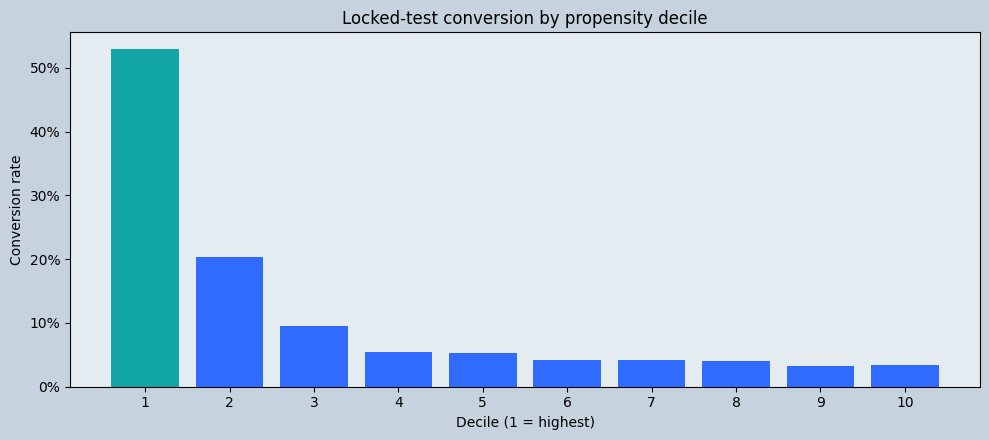

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor='#CEC8E3')
ax.set_facecolor('#E1DCF0')
colors = ['#13A6A6' if value == 1 else '#2F6BFF' for value in deciles['locked_test_decile']]
ax.bar(deciles['locked_test_decile'].astype(str), deciles['conversion_rate'], color=colors)
ax.set(title='Locked-test conversion by propensity decile', xlabel='Decile (1 = highest)', ylabel='Conversion rate')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.tight_layout()
plt.show()

## 3. Stability and subgroup diagnostics
PSI compares training and locked-test populations. Subgroup tables are monitoring diagnostics, not a complete fairness certification because protected attributes are unavailable.

In [5]:
governance_summary = pd.Series({
    'expected_calibration_error': governance['expected_calibration_error'],
    'maximum_psi': governance['max_psi'],
    'drift_status': governance['drift_status'],
    'eligible_subgroup_rows': int(subgroups['minimum_volume_pass'].sum()),
}, name='value')
governance_summary, drift.nlargest(10, 'psi')[['feature', 'psi', 'status']], importance.head(10)

(expected_calibration_error    0.009318
 maximum_psi                   0.001605
 drift_status                    stable
 eligible_subgroup_rows              29
 Name: value, dtype: object,
            feature       psi  status
 0              job  0.001605  stable
 1              age  0.001545  stable
 2        euribor3m  0.001171  stable
 3            month  0.001065  stable
 4         age_band  0.000600  stable
 5         campaign  0.000483  stable
 6      nr.employed  0.000345  stable
 7         poutcome  0.000224  stable
 8  education_group  0.000183  stable
 9         previous  0.000158  stable,
                                              feature  importance  direction
 0                                        nr.employed    0.588386  magnitude
 1                                              pdays    0.078371  magnitude
 2                                          euribor3m    0.070539  magnitude
 3                                      cons.conf.idx    0.055583  magnitude
 4     

## 4. Reproducibility gate
These checks lock the headline model evidence to the governed outputs.

In [6]:
top_decile_rate = deciles.loc[deciles['locked_test_decile'].eq(1), 'conversion_rate'].iloc[0]
notebook_assertions = {
    'duration_excluded': metrics['modeling_policy']['duration_excluded'] is True,
    'locked_test_size': len(evaluation) == metrics['locked_test_observation_count'] == 8238,
    'ten_deciles': deciles['locked_test_decile'].nunique() == 10,
    'top_decile_reconciled': abs(top_decile_rate - metrics['top_decile_conversion_rate']) < 1e-12,
    'probabilities_bounded': evaluation['evaluation_probability'].between(0, 1).all(),
    'drift_status_valid': governance['drift_status'] in {'stable', 'moderate', 'high'},
}
assert all(notebook_assertions.values()), notebook_assertions
pd.Series(notebook_assertions, name='PASS')

duration_excluded        True
locked_test_size         True
ten_deciles              True
top_decile_reconciled    True
probabilities_bounded    True
drift_status_valid       True
Name: PASS, dtype: bool